In [1]:
# ============================================
# SmartGrid Dissertation - Data Exploration
# Dataset: UCI Household Electric Power Consumption
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import urllib.request
import zipfile

print("All libraries loaded successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")

All libraries loaded successfully!
Pandas version: 3.0.3
Numpy version: 2.4.6


In [2]:
# ============================================
# Download UCI Household Power Consumption Dataset
# ============================================

import urllib.request
import zipfile
import os

# Create data folder if it doesn't exist
os.makedirs('../data', exist_ok=True)

# Download the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00235/household_power_consumption.zip"

print("Downloading dataset... please wait (this may take 1-2 minutes)...")
urllib.request.urlretrieve(url, '../data/household_power_consumption.zip')
print("Download complete!")

# Unzip the file
print("Extracting files...")
with zipfile.ZipFile('../data/household_power_consumption.zip', 'r') as zip_ref:
    zip_ref.extractall('../data/')
print("Extraction complete!")

# Check the file is there
files = os.listdir('../data/')
print(f"Files in data folder: {files}")

Download complete!
Extracting files...
Extraction complete!
Files in data folder: ['household_power_consumption.txt', 'household_power_consumption.zip']


In [4]:
# ============================================
# Load and Inspect the Dataset (Fixed)
# ============================================

# Load the dataset
df = pd.read_csv('../data/household_power_consumption.txt', 
                  sep=';', 
                  low_memory=False,
                  na_values=['?'])

# Combine Date and Time into one datetime column
df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], 
                                 dayfirst=True)

# Drop original Date and Time columns
df = df.drop(columns=['Date', 'Time'])

# Move datetime to first column
cols = ['datetime'] + [col for col in df.columns if col != 'datetime']
df = df[cols]

print("Dataset loaded successfully!")
print(f"\nShape: {df.shape}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"\nColumn names:")
for col in df.columns:
    print(f"  - {col}")
print(f"\nDate range: {df['datetime'].min()} to {df['datetime'].max()}")
print(f"\nMissing values per column:")
print(df.isnull().sum())

Dataset loaded successfully!

Shape: (2075259, 8)
Rows: 2,075,259
Columns: 8

Column names:
  - datetime
  - Global_active_power
  - Global_reactive_power
  - Voltage
  - Global_intensity
  - Sub_metering_1
  - Sub_metering_2
  - Sub_metering_3

Date range: 2006-12-16 17:24:00 to 2010-11-26 21:02:00

Missing values per column:
datetime                     0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64


In [6]:
# ============================================
# Data Cleaning (Fixed)
# ============================================

print(f"Before cleaning: {df.shape[0]:,} rows")
print(f"Missing values: {df.isnull().sum().sum():,}")

# Step 1 - Sort by datetime
df = df.sort_values('datetime')
df = df.reset_index(drop=True)

# Step 2 - Forward fill missing values (updated syntax for newer pandas)
df = df.ffill()

# Step 3 - Convert all energy columns to numeric
energy_cols = ['Global_active_power', 'Global_reactive_power', 
               'Voltage', 'Global_intensity', 
               'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

for col in energy_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Step 4 - Drop any remaining nulls
df = df.dropna()

# Step 5 - Set datetime as index
df = df.set_index('datetime')

print(f"\nAfter cleaning: {df.shape[0]:,} rows")
print(f"Missing values remaining: {df.isnull().sum().sum()}")
print(f"\nData types:")
print(df.dtypes)
print(f"\nBasic statistics:")
print(df.describe().round(3))

Before cleaning: 2,075,259 rows
Missing values: 181,853

After cleaning: 2,075,259 rows
Missing values remaining: 0

Data types:
Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object

Basic statistics:
       Global_active_power  Global_reactive_power      Voltage  \
count          2075259.000            2075259.000  2075259.000   
mean                 1.086                  0.123      240.842   
std                  1.053                  0.113        3.236   
min                  0.076                  0.000      223.200   
25%                  0.308                  0.048      239.000   
50%                  0.598                  0.100      241.020   
75%                  1.524                  0.194      242.870   
max                 11.122                  1.390      254.150   

       Globa

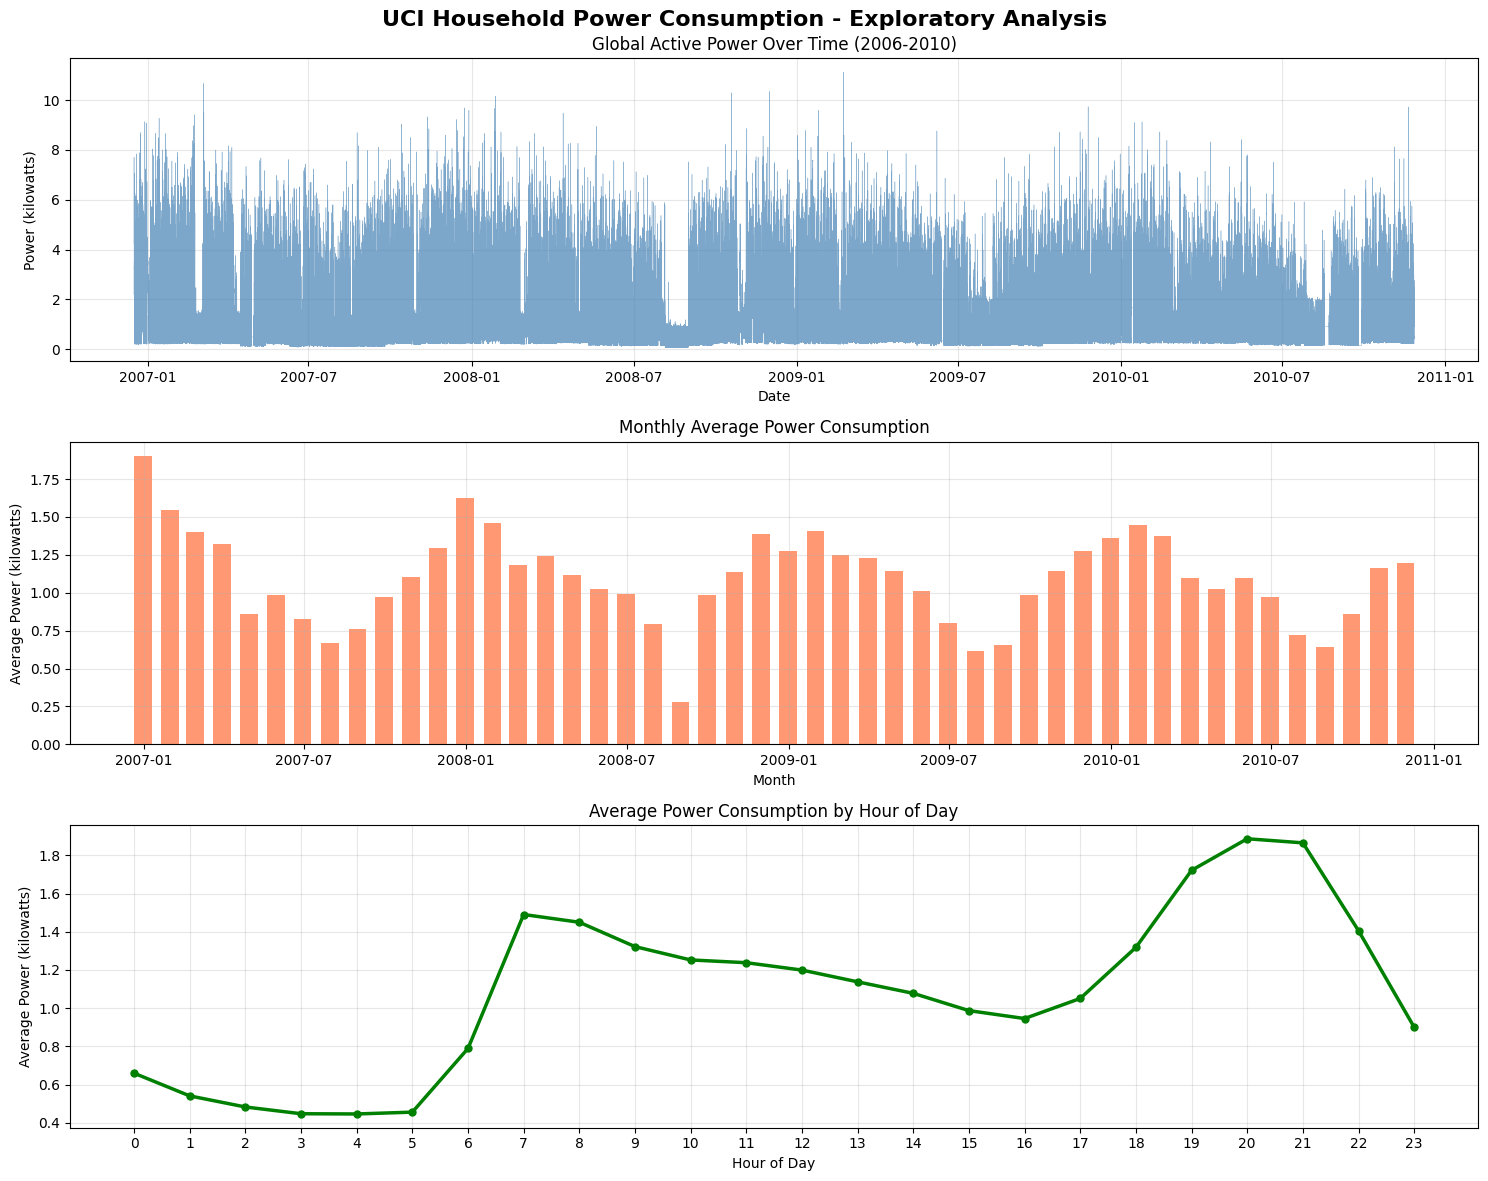

Graph saved to results folder!


In [7]:
# ============================================
# Exploratory Data Analysis - Visualisations
# ============================================

fig, axes = plt.subplots(3, 1, figsize=(15, 12))
fig.suptitle('UCI Household Power Consumption - Exploratory Analysis', 
             fontsize=16, fontweight='bold')

# Plot 1 - Full time series of Global Active Power
axes[0].plot(df.index, df['Global_active_power'], 
             color='steelblue', linewidth=0.3, alpha=0.7)
axes[0].set_title('Global Active Power Over Time (2006-2010)')
axes[0].set_ylabel('Power (kilowatts)')
axes[0].set_xlabel('Date')
axes[0].grid(True, alpha=0.3)

# Plot 2 - Monthly average power consumption
monthly_avg = df['Global_active_power'].resample('ME').mean()
axes[1].bar(monthly_avg.index, monthly_avg.values, 
            color='coral', alpha=0.8, width=20)
axes[1].set_title('Monthly Average Power Consumption')
axes[1].set_ylabel('Average Power (kilowatts)')
axes[1].set_xlabel('Month')
axes[1].grid(True, alpha=0.3)

# Plot 3 - Hourly average power (daily pattern)
hourly_avg = df.groupby(df.index.hour)['Global_active_power'].mean()
axes[2].plot(hourly_avg.index, hourly_avg.values, 
             color='green', linewidth=2.5, marker='o', markersize=5)
axes[2].set_title('Average Power Consumption by Hour of Day')
axes[2].set_ylabel('Average Power (kilowatts)')
axes[2].set_xlabel('Hour of Day')
axes[2].set_xticks(range(0, 24))
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/01_exploratory_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graph saved to results folder!")

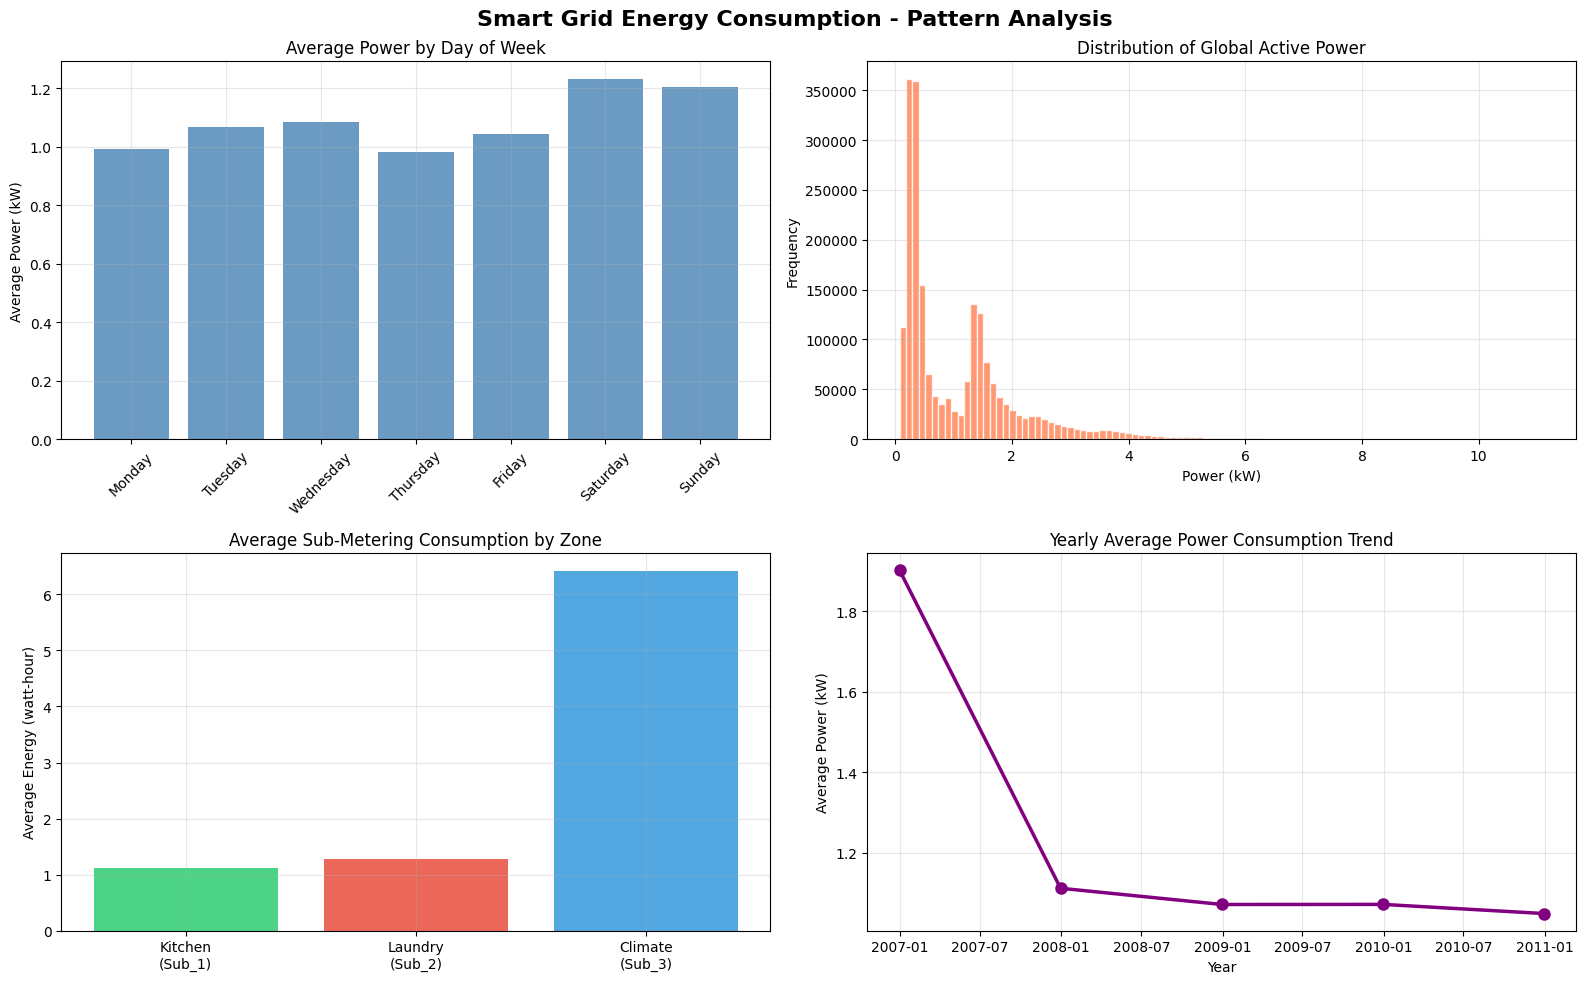

Pattern analysis graphs saved!


In [8]:
# ============================================
# Deeper Analysis - Patterns & Distributions
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Smart Grid Energy Consumption - Pattern Analysis', 
             fontsize=16, fontweight='bold')

# Plot 1 - Day of week pattern
daily_avg = df.groupby(df.index.dayofweek)['Global_active_power'].mean()
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
axes[0,0].bar(days, daily_avg.values, color='steelblue', alpha=0.8)
axes[0,0].set_title('Average Power by Day of Week')
axes[0,0].set_ylabel('Average Power (kW)')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].grid(True, alpha=0.3)

# Plot 2 - Power distribution
axes[0,1].hist(df['Global_active_power'], bins=100, 
               color='coral', alpha=0.8, edgecolor='white')
axes[0,1].set_title('Distribution of Global Active Power')
axes[0,1].set_xlabel('Power (kW)')
axes[0,1].set_ylabel('Frequency')
axes[0,1].grid(True, alpha=0.3)

# Plot 3 - Sub metering comparison
sub_means = [df['Sub_metering_1'].mean(), 
             df['Sub_metering_2'].mean(), 
             df['Sub_metering_3'].mean()]
sub_labels = ['Kitchen\n(Sub_1)', 'Laundry\n(Sub_2)', 'Climate\n(Sub_3)']
colors = ['#2ecc71', '#e74c3c', '#3498db']
axes[1,0].bar(sub_labels, sub_means, color=colors, alpha=0.85)
axes[1,0].set_title('Average Sub-Metering Consumption by Zone')
axes[1,0].set_ylabel('Average Energy (watt-hour)')
axes[1,0].grid(True, alpha=0.3)

# Plot 4 - Yearly trend
yearly_avg = df['Global_active_power'].resample('YE').mean()
axes[1,1].plot(yearly_avg.index, yearly_avg.values, 
               color='purple', linewidth=2.5, marker='o', markersize=8)
axes[1,1].set_title('Yearly Average Power Consumption Trend')
axes[1,1].set_ylabel('Average Power (kW)')
axes[1,1].set_xlabel('Year')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/02_pattern_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Pattern analysis graphs saved!")

In [9]:
# ============================================
# Save Clean Dataset for ML Training
# ============================================

# Resample to hourly data (better for LSTM training)
df_hourly = df.resample('h').mean()
df_hourly = df_hourly.ffill()

print(f"Original data (1-min): {df.shape[0]:,} rows")
print(f"Hourly resampled data: {df_hourly.shape[0]:,} rows")
print(f"\nDate range: {df_hourly.index.min()} to {df_hourly.index.max()}")
print(f"Missing values after resample: {df_hourly.isnull().sum().sum()}")

# Save the clean hourly dataset
df_hourly.to_csv('../data/clean_hourly_power.csv')
print("\nClean hourly dataset saved to data/clean_hourly_power.csv")
print("This file will be used for LSTM training!")

# Quick preview
print(f"\nFirst 5 rows:")
print(df_hourly.head())

Original data (1-min): 2,075,259 rows
Hourly resampled data: 34,589 rows

Date range: 2006-12-16 17:00:00 to 2010-11-26 21:00:00
Missing values after resample: 0

Clean hourly dataset saved to data/clean_hourly_power.csv
This file will be used for LSTM training!

First 5 rows:
                     Global_active_power  Global_reactive_power     Voltage  \
datetime                                                                      
2006-12-16 17:00:00             4.222889               0.229000  234.643889   
2006-12-16 18:00:00             3.632200               0.080033  234.580167   
2006-12-16 19:00:00             3.400233               0.085233  233.232500   
2006-12-16 20:00:00             3.268567               0.075100  234.071500   
2006-12-16 21:00:00             3.056467               0.076667  237.158667   

                     Global_intensity  Sub_metering_1  Sub_metering_2  \
datetime                                                                
2006-12-16 17:00:00   